# Disease Prediction

## CodeAlpha Machine Learning Internship

This project builds a machine learning model to predict diseases based on patient symptoms using a classification approach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Dataset Loading and Understanding

The dataset contains patient medical information and a target variable indicating the presence of heart disease.

In [2]:
# Load the Heart Disease dataset

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

data = pd.read_csv(
    "../data/heart_disease.csv",
    names=columns,
    na_values="?"
)

print("Dataset shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## 3. Data Preprocessing

The dataset contains a small number of missing values in the `ca` and `thal` features. These values are replaced using the most frequent value of each feature.

In [3]:
# Handle missing values

data["ca"] = data["ca"].fillna(data["ca"].mode()[0])
data["thal"] = data["thal"].fillna(data["thal"].mode()[0])

print("Missing values after preprocessing:")
print(data.isnull().sum())

Missing values after preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 4. Exploratory Data Analysis

Let's examine the distribution of the target variable to understand the number of patients with and without heart disease.

Target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


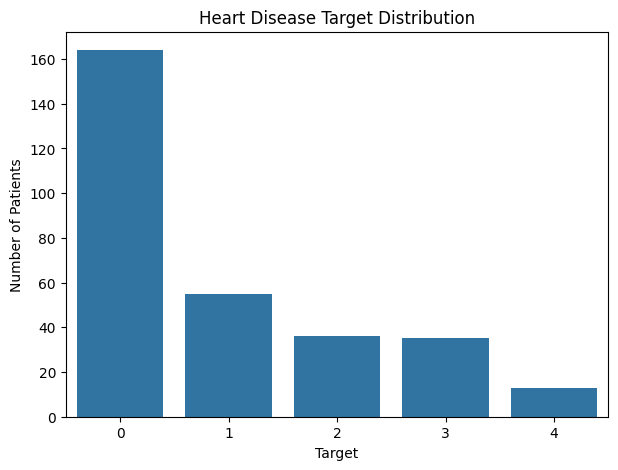

In [4]:
# Check target distribution

print("Target distribution:")
print(data["target"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x="target", data=data)
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.show()

## 5. Feature and Target Preparation

The original target contains values from 0 to 4. For binary disease prediction, values greater than 0 are treated as the presence of heart disease.

In [5]:
# Convert target into binary classification
data["target"] = (data["target"] > 0).astype(int)

# Separate features and target
X = data.drop("target", axis=1)
y = data["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:")
print(y.value_counts())

Feature shape: (303, 13)
Target shape: (303,)

Target classes:
target
0    164
1    139
Name: count, dtype: int64


## 6. Train-Test Split

The dataset is divided into training and testing sets. The model will learn from the training data and be evaluated on unseen testing data.

In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


## 7. Model Training

A Random Forest Classifier is used to learn the relationship between the medical features and the presence or absence of heart disease.

In [7]:
# Create and train the Random Forest model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## 8. Model Evaluation

The trained Random Forest model is evaluated on the unseen test dataset using accuracy and a classification report.

In [8]:
# Make predictions on the test data

y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 88.52%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



## 9. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

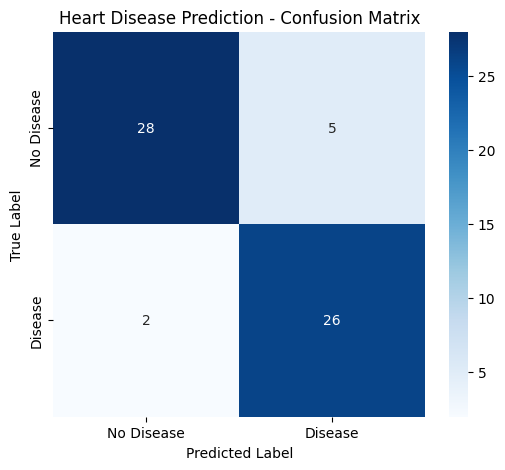

In [9]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Heart Disease Prediction - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 10. Model Saving

The trained Random Forest model is saved using Joblib so it can be reused later without retraining.

In [10]:
# Save the trained model

joblib.dump(model, "../models/disease_prediction_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


## 11. Saved Model Verification

The saved model is loaded again and used to make a sample prediction.

In [11]:
# Load the saved model

loaded_model = joblib.load("../models/disease_prediction_random_forest.pkl")

# Make a prediction using one test sample
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)[0]

print("Actual value:", y_test.iloc[0])
print("Predicted value:", prediction)

if prediction == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

Actual value: 0
Predicted value: 0
Prediction: No Heart Disease


## 12. Final Model Results

In [12]:
print("Final Model Results")
print("-------------------")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Model: Random Forest Classifier")
print("Dataset: UCI Heart Disease Dataset")

Final Model Results
-------------------
Test Accuracy: 88.52%
Model: Random Forest Classifier
Dataset: UCI Heart Disease Dataset
